In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv('C:/Users/USER/Desktop/project/AIML Dataset.csv')
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [4]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [5]:
x = df.drop(['id', 'isFraud'], axis=1, errors='ignore')
y = df['isFraud']

In [6]:
print(x.columns.tolist())

['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFlaggedFraud']


In [7]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [8]:
x_train.shape

(5090096, 10)

In [9]:
x_test.shape

(1272524, 10)

In [10]:
print(x_train.dtypes)

step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFlaggedFraud      int64
dtype: object


In [11]:
print(x_train.head())

         step      type     amount    nameOrig  oldbalanceOrg  newbalanceOrig  \
6271196   619   CASH_IN  386385.08  C421351828     4669568.85      5055953.92   
1888243   164   CASH_IN  212458.78   C83569848      234635.00       447093.78   
5549957   382   PAYMENT   19967.60  C852995095        3634.00            0.00   
2025342   180  CASH_OUT  527616.51   C61761046      180216.00            0.00   
682342     36  TRANSFER  206067.85  C758004147           0.00            0.00   

            nameDest  oldbalanceDest  newbalanceDest  isFlaggedFraud  
6271196  C1977099364       506035.06       119649.98               0  
1888243  C1690589535       806037.88       593579.10               0  
5549957  M1695416333            0.00            0.00               0  
2025342   C577654587        92157.10       619773.61               0  
682342   C2143015292      2131494.48      2337562.32               0  


In [12]:
print(type(x_train))

<class 'pandas.core.frame.DataFrame'>


In [13]:
# Only keep numbers for the scaler
x_train_numeric = x_train.select_dtypes(include=['number'])
x_test_numeric = x_test.select_dtypes(include=['number'])

In [14]:
# Then scale those
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_numeric)
x_test_scaled = scaler.transform(x_test_numeric)

In [15]:
print(pd.Series(y_train).value_counts(normalize=True))

isFraud
0    0.998705
1    0.001295
Name: proportion, dtype: float64


In [16]:
rf_model = RandomForestClassifier(
n_estimators=100,
max_depth=10,
min_samples_split=5,
random_state=42,
    n_jobs=-1
)

In [17]:
# Cross-validation
cv_scores = cross_val_score(rf_model, x_train_scaled, y_train, cv=5, scoring='f1')

print("\ncross_val_score F1 scores:", cv_scores)
print("Average F1 scores:", np.mean(cv_scores))


cross_val_score F1 scores: [0.6933729  0.67168675 0.68389662 0.68815072 0.67567568]
Average F1 scores: 0.682556531990414


In [18]:
rf_model.fit(x_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [19]:
y_pred = rf_model.predict(x_test_scaled)

In [21]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270904
           1       0.99      0.53      0.69      1620

    accuracy                           1.00   1272524
   macro avg       1.00      0.77      0.85   1272524
weighted avg       1.00      1.00      1.00   1272524



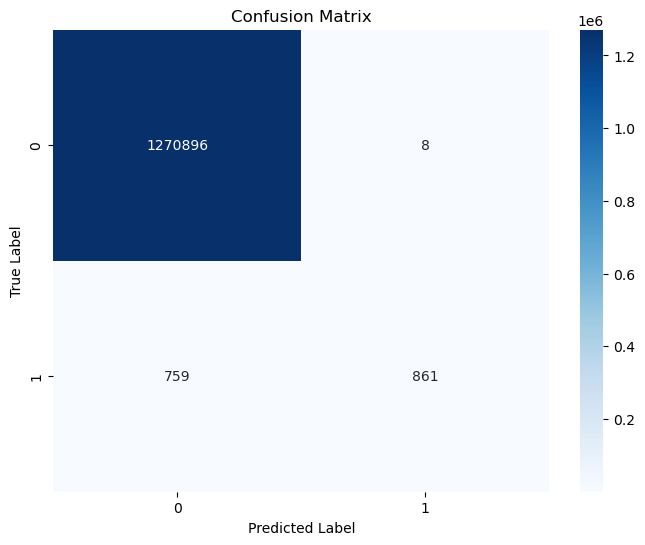

In [23]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [29]:
print(len(x.columns), len(importance))

10 7


In [35]:
for f, i in zip(x.columns, importance):
    print(f, i)

step 0.1107249975452405
type 0.1283261226666944
amount 0.4907139732943815
nameOrig 0.06384015421576139
oldbalanceOrg 0.037404776804081184
newbalanceOrig 0.16733306885551447
nameDest 0.0016569066183265352


In [38]:
feature_names = x_train_numeric.columns

In [40]:
feature_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

In [41]:
feature_imp.head()

,Feature,Importance
2,oldbalanceOrg,0.490714
5,newbalanceDest,0.167333
1,amount,0.128326
0,step,0.110725
3,newbalanceOrig,0.063840


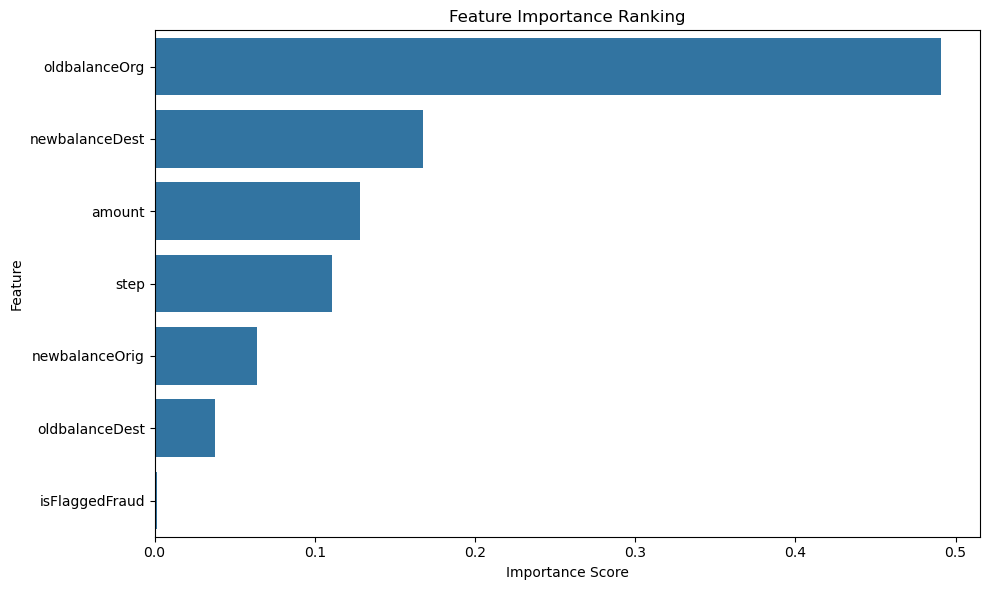

In [42]:
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_imp, x='Importance', y='Feature')
plt.title('Feature Importance Ranking')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()


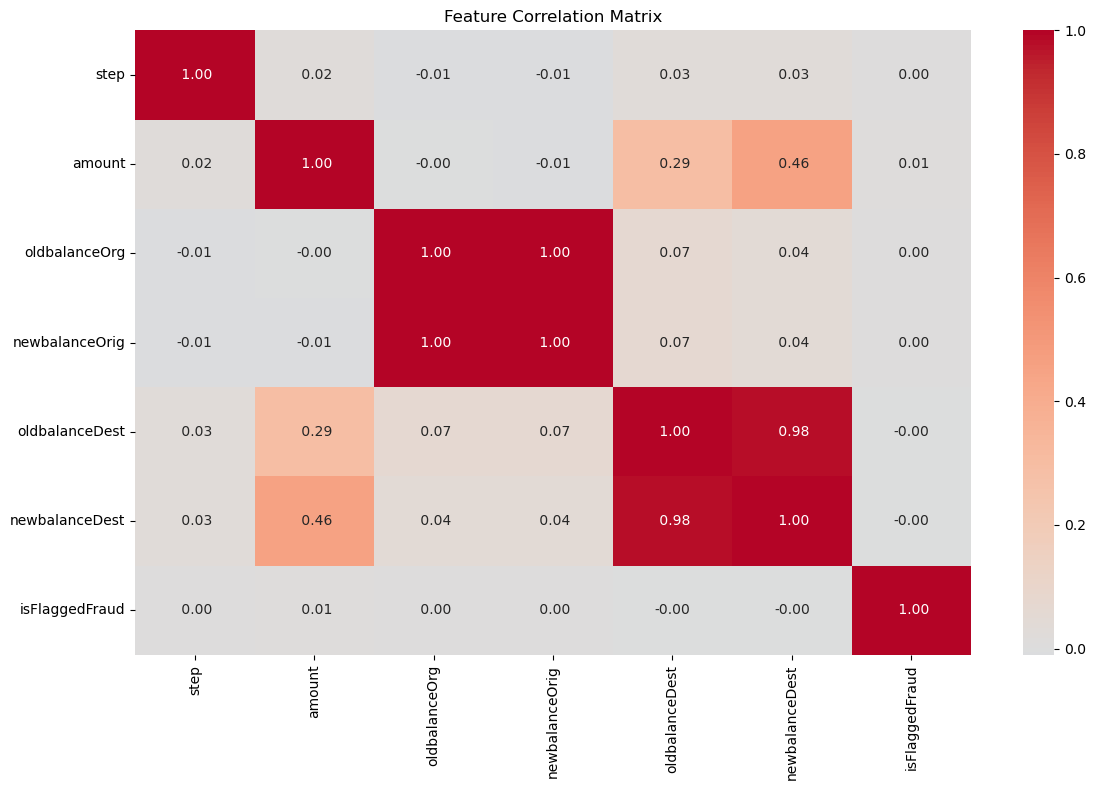

In [46]:
plt.figure(figsize=(12, 8))
correlation_matrix = x.corr(numeric_only=True)
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0, annot=True, fmt=' .2f')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [47]:
y_pred_proba = rf_model.predict_proba(x_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

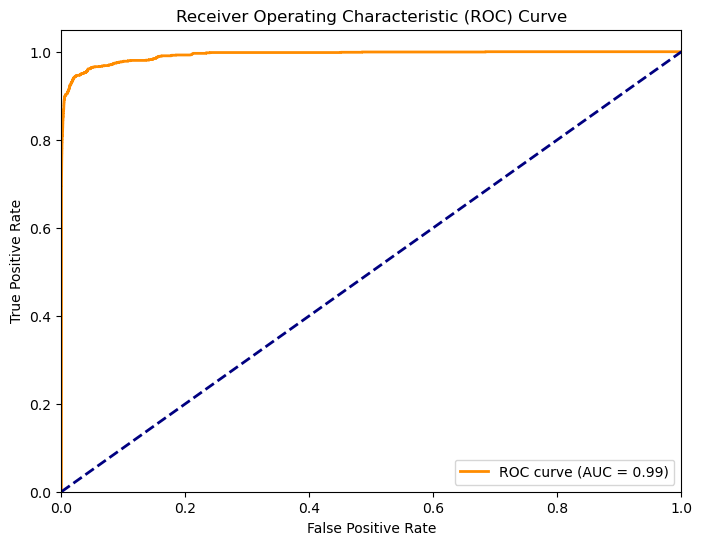

In [48]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()
           